<a href="https://colab.research.google.com/github/Not-kh-lily-23/pulsar-conformal-triage/blob/main/main_triage_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
success
now we will train
probabilities are generated now we'll start caliberation
caliberation


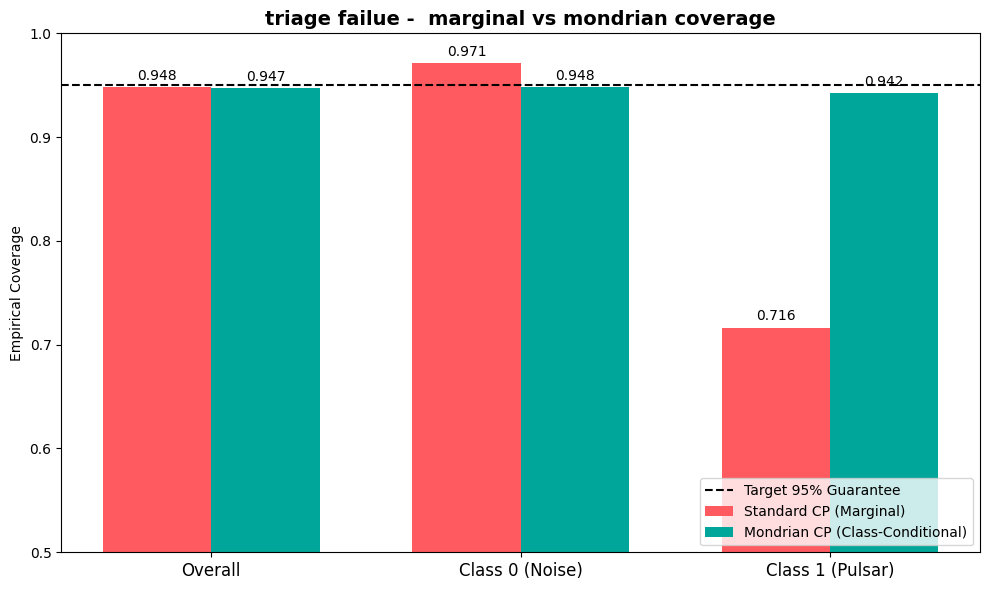

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score
from google.colab import drive
drive.mount('/content/drive')
processed='/content/drive/MyDrive/pulsar_project/data/processed'
try:
    trn_df=pd.read_csv(f"{processed}/train.csv")
    calib_df=pd.read_csv(f"{processed}/calib.csv")
    tst_df=pd.read_csv(f"{processed}/test.csv")
    print("success")
except FileNotFoundError:
    raise Exception("data not found")
x_train,y_train=trn_df.drop(columns=["target"]),trn_df["target"]
x_calib,y_calib=calib_df.drop(columns=["target"]),calib_df["target"]
x_test,y_test=tst_df.drop(columns=["target"]),tst_df["target"]
print("now we will train")
clf=lgb.LGBMClassifier(random_state=42,n_estimators=100,verbose=-1)
clf.fit(x_train,y_train)
calib_probs=clf.predict_proba(x_calib)
test_probs=clf.predict_proba(x_test)
print("probabilities are generated now we'll start caliberation")
print("caliberation")
calib_scores=1-calib_probs[np.arange(len(y_calib)),y_calib]
tstc=1-test_probs[np.arange(len(y_test)),y_test]
alpha=0.05
n=len(y_calib)
q_level=np.ceil((n+1)*(1-alpha))/n
marg_q=np.quantile(calib_scores,min(1.0,q_level))
marg_cov_0=np.mean(tstc[y_test==0]<=marg_q)
marg_cov_1=np.mean(tstc[y_test==1]<=marg_q)
marg_cov_overall=np.mean(tstc<=marg_q)
scores_0=calib_scores[y_calib==0]
scores_1=calib_scores[y_calib==1]
n_0=len(scores_0)
q_level_0=np.ceil((n_0+1)*(1-alpha))/n_0
q_0=np.quantile(scores_0,min(1.0,q_level_0))
n_1=len(scores_1)
q_level_1=np.ceil((n_1+1)*(1-alpha))/n_1
q_1=np.quantile(scores_1,min(1.0,q_level_1))
mdr_cov_0=np.mean(tstc[y_test==0]<=q_0)
mdr_cov_1=np.mean(tstc[y_test==1]<=q_1)
mdr_cov_overall=np.mean(tstc<=np.where(y_test==0,q_0,q_1))
labels=['Overall','Class 0 (Noise)','Class 1 (Pulsar)']
marg_bars=[marg_cov_overall,marg_cov_0,marg_cov_1]
mdr_bars=[mdr_cov_overall,mdr_cov_0,mdr_cov_1]
x=np.arange(len(labels))
width=0.35
fig,ax=plt.subplots(figsize=(10, 6))
rects1=ax.bar(x-width/2,marg_bars,width,label='Standard CP (Marginal)',color='#ff5a5f')
rects2=ax.bar(x+width/2,mdr_bars,width,label='Mondrian CP (Class-Conditional)',color='#00a699')
ax.axhline(y=0.95,color='black',linestyle='--',label='Target 95% Guarantee')
ax.set_ylabel('Empirical Coverage')
ax.set_title('triage failue -  marginal vs mondrian coverage',fontsize=14,fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels,fontsize=12)
ax.set_ylim(0.5,1.0)
ax.legend(loc='lower right')
for rect in rects1 + rects2:
    height=rect.get_height()
    ax.annotate(f'{height:.3f}',xy=(rect.get_x()+rect.get_width()/2,height),
                xytext=(0, 3),textcoords="offset points",ha='center',va='bottom',fontsize=10)
plt.tight_layout()
plt.show()